In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import gzip
import struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

%matplotlib inline

In [3]:
ruta_dataset = "/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab05"

print(os.listdir(ruta_dataset))

['emnist-letters-train-images-idx3-ubyte.gz', 'emnist-letters-train-labels-idx1-ubyte.gz', 'emnist-letters-test-images-idx3-ubyte.gz', 'emnist-letters-mapping.txt', 'emnist-letters-test-labels-idx1-ubyte.gz']


In [4]:
def cargar_imagenes_idx(ruta):
    with gzip.open(ruta, 'rb') as archivo:
        magic, cantidad, filas, columnas = struct.unpack(
            ">IIII", archivo.read(16)
        )

        imagenes = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

        imagenes = imagenes.reshape(
            cantidad, filas, columnas
        )

    return imagenes


def cargar_etiquetas_idx(ruta):
    with gzip.open(ruta, 'rb') as archivo:
        magic, cantidad = struct.unpack(
            ">II", archivo.read(8)
        )

        etiquetas = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

    return etiquetas

In [6]:
train_images = cargar_imagenes_idx(
    os.path.join(
        ruta_dataset,
        "emnist-letters-train-images-idx3-ubyte.gz"
    )
)

train_labels = cargar_etiquetas_idx(
    os.path.join(
        ruta_dataset,
        "emnist-letters-train-labels-idx1-ubyte.gz"
    )
)

test_images = cargar_imagenes_idx(
    os.path.join(
        ruta_dataset,
        "emnist-letters-test-images-idx3-ubyte.gz"
    )
)

test_labels = cargar_etiquetas_idx(
    os.path.join(
        ruta_dataset,
        "emnist-letters-test-labels-idx1-ubyte.gz"
    )
)

In [7]:
test_images = cargar_imagenes_idx(
    os.path.join(
        ruta_dataset,
        "emnist-letters-test-images-idx3-ubyte.gz"
    )
)

In [8]:
print("Train imágenes:", train_images.shape)
print("Train etiquetas:", train_labels.shape)

print("Test imágenes:", test_images.shape)
print("Test etiquetas:", test_labels.shape)

Train imágenes: (124800, 28, 28)
Train etiquetas: (124800,)
Test imágenes: (20800, 28, 28)
Test etiquetas: (20800,)


In [9]:
imagenes = np.concatenate(
    (train_images, test_images),
    axis=0
)

etiquetas = np.concatenate(
    (train_labels, test_labels),
    axis=0
)

print("Dimensión imágenes:", imagenes.shape)
print("Dimensión etiquetas:", etiquetas.shape)
print("Cantidad total:", len(etiquetas))

Dimensión imágenes: (145600, 28, 28)
Dimensión etiquetas: (145600,)
Cantidad total: 145600


In [10]:
etiquetas = etiquetas - 1

print("Etiqueta mínima:", etiquetas.min())
print("Etiqueta máxima:", etiquetas.max())
print("Número de clases:", len(np.unique(etiquetas)))

Etiqueta mínima: 0
Etiqueta máxima: 25
Número de clases: 26


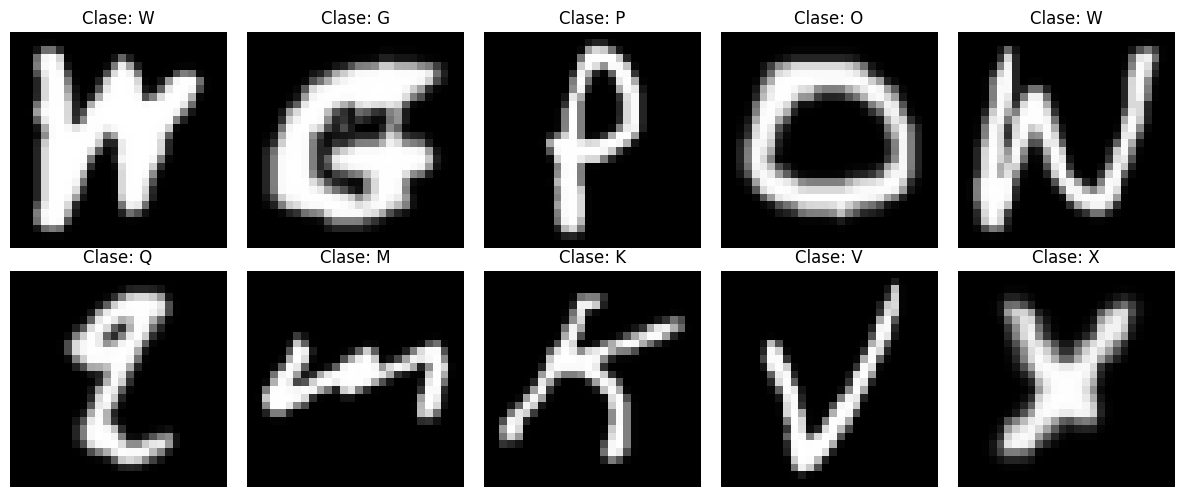

In [11]:
nombres_clases = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):

    # EMNIST necesita transposición para visualizar correctamente
    imagen = imagenes[i].T

    ax.imshow(imagen, cmap="gray")
    ax.set_title(
        f"Clase: {nombres_clases[etiquetas[i]]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
df_etiquetas = pd.DataFrame({
    "clase": etiquetas
})

df_etiquetas["letra"] = df_etiquetas["clase"].map(
    lambda x: nombres_clases[x]
)

df_etiquetas.head(10)

,clase,letra
0,22,W
1,6,G
2,15,P
3,14,O
4,22,W
5,16,Q
6,12,M
7,10,K
8,21,V
9,23,X


In [13]:
balance_clases = (
    df_etiquetas["letra"]
    .value_counts()
    .sort_index()
)

print(balance_clases)

letra
A    5600
B    5600
C    5600
D    5600
E    5600
F    5600
G    5600
H    5600
I    5600
J    5600
K    5600
L    5600
M    5600
N    5600
O    5600
P    5600
Q    5600
R    5600
S    5600
T    5600
U    5600
V    5600
W    5600
X    5600
Y    5600
Z    5600
Name: count, dtype: int64


In [14]:
X = imagenes.reshape(
    imagenes.shape[0],
    28 * 28
)

y = etiquetas.copy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (145600, 784)
Forma de y: (145600,)


In [15]:
X = X.astype(np.float32) / 255.0

In [16]:
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())

Valor mínimo: 0.0
Valor máximo: 1.0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("===== ENTRENAMIENTO =====")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\n===== PRUEBA =====")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

===== ENTRENAMIENTO =====
X_train: (116480, 784)
y_train: (116480,)

===== PRUEBA =====
X_test: (29120, 784)
y_test: (29120,)


In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
def costo_gradiente(theta, X, y, lambda_):
    m = len(y)

    h = sigmoid(X @ theta)

    epsilon = 1e-10

    costo = (
        (-1 / m)
        * (
            y @ np.log(h + epsilon)
            + (1 - y) @ np.log(1 - h + epsilon)
        )
    )

    costo += (
        lambda_ / (2 * m)
    ) * np.sum(theta[1:] ** 2)

    grad = (1 / m) * (X.T @ (h - y))

    grad[1:] += (
        lambda_ / m
    ) * theta[1:]

    return costo, grad

In [22]:
X_train_bias = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_bias = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]

print(X_train_bias.shape)
print(X_test_bias.shape)

(116480, 785)
(29120, 785)


In [23]:
def entrenar_one_vs_all(
    X,
    y,
    num_clases,
    lambda_=0.1,
    maxiter=50
):

    n = X.shape[1]

    todos_theta = np.zeros(
        (num_clases, n)
    )

    historial_costos = []

    for clase in range(num_clases):

        print(
            f"Entrenando clase "
            f"{clase + 1}/{num_clases}..."
        )

        y_binaria = (
            y == clase
        ).astype(int)

        theta_inicial = np.zeros(n)

        costos_clase = []

        def callback(theta_actual):

            costo, _ = costo_gradiente(
                theta_actual,
                X,
                y_binaria,
                lambda_
            )

            costos_clase.append(costo)

        resultado = optimize.minimize(
            fun=lambda theta:
                costo_gradiente(
                    theta,
                    X,
                    y_binaria,
                    lambda_
                ),
            x0=theta_inicial,
            jac=True,
            method="L-BFGS-B",
            callback=callback,
            options={
                "maxiter": maxiter
            }
        )

        todos_theta[clase] = resultado.x

        historial_costos.append(
            costos_clase
        )

        print(
            "Costo final:",
            round(resultado.fun, 5)
        )

    return todos_theta, historial_costos

In [24]:
num_clases = 26

todos_theta, historial_costos = entrenar_one_vs_all(
    X_train_bias,
    y_train,
    num_clases=num_clases,
    lambda_=0.1,
    maxiter=50
)

Entrenando clase 1/26...
Costo final: 0.09785
Entrenando clase 2/26...
Costo final: 0.07686
Entrenando clase 3/26...
Costo final: 0.0498
Entrenando clase 4/26...
Costo final: 0.0854
Entrenando clase 5/26...
Costo final: 0.06725
Entrenando clase 6/26...
Costo final: 0.05896
Entrenando clase 7/26...
Costo final: 0.10112
Entrenando clase 8/26...
Costo final: 0.07532
Entrenando clase 9/26...
Costo final: 0.07023
Entrenando clase 10/26...
Costo final: 0.05306
Entrenando clase 11/26...
Costo final: 0.07734
Entrenando clase 12/26...
Costo final: 0.07096
Entrenando clase 13/26...
Costo final: 0.02982
Entrenando clase 14/26...
Costo final: 0.07883
Entrenando clase 15/26...
Costo final: 0.04841
Entrenando clase 16/26...
Costo final: 0.04725
Entrenando clase 17/26...
Costo final: 0.08693
Entrenando clase 18/26...
Costo final: 0.08052
Entrenando clase 19/26...
Costo final: 0.04319
Entrenando clase 20/26...
Costo final: 0.09565
Entrenando clase 21/26...
Costo final: 0.07192
Entrenando clase 22/26..

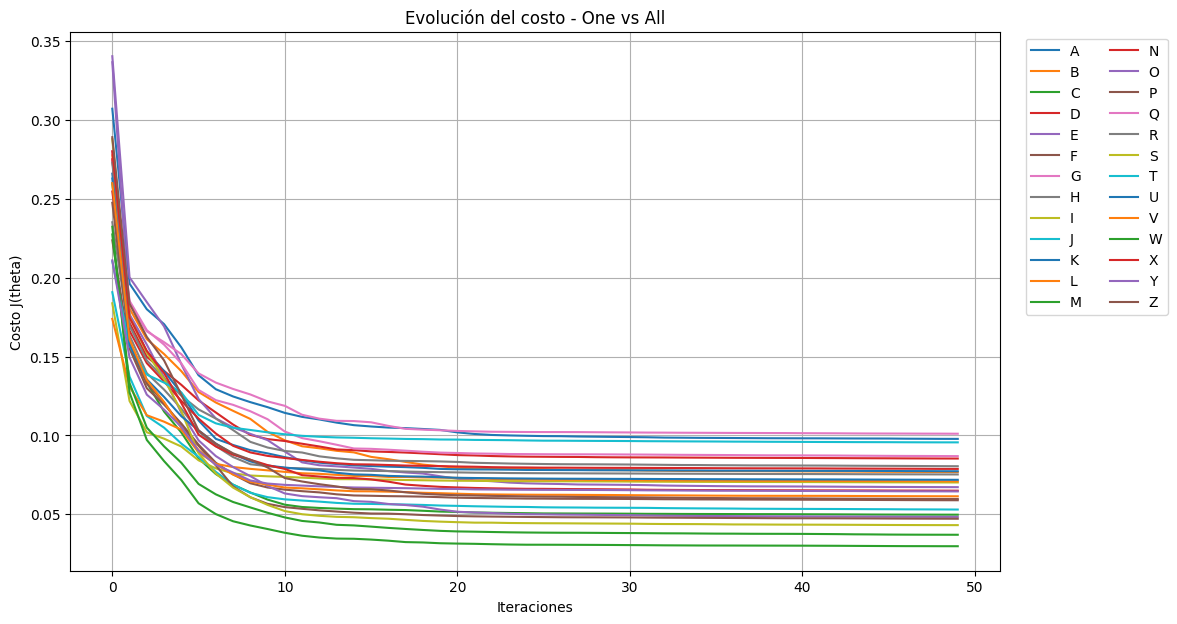

In [25]:
plt.figure(figsize=(12, 7))

for clase, costos in enumerate(historial_costos):
    plt.plot(
        costos,
        label=nombres_clases[clase]
    )

plt.title(
    "Evolución del costo - One vs All"
)
plt.xlabel("Iteraciones")
plt.ylabel("Costo J(theta)")
plt.legend(
    ncol=2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid()
plt.show()

In [26]:
def predecir_one_vs_all(X, todos_theta):

    probabilidades = sigmoid(
        X @ todos_theta.T
    )

    predicciones = np.argmax(
        probabilidades,
        axis=1
    )

    return predicciones, probabilidades

In [27]:
pred_train, prob_train = predecir_one_vs_all(
    X_train_bias,
    todos_theta
)

precision_train = accuracy_score(
    y_train,
    pred_train
)

print(
    "Precisión entrenamiento:",
    round(precision_train * 100, 2),
    "%"
)

Precisión entrenamiento: 72.28 %


In [28]:
pred_test, prob_test = predecir_one_vs_all(
    X_test_bias,
    todos_theta
)

precision_test = accuracy_score(
    y_test,
    pred_test
)

print(
    "Precisión prueba:",
    round(precision_test * 100, 2),
    "%"
)

Precisión prueba: 71.21 %


In [29]:
resultados_precision = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "Precision": [
        precision_train * 100,
        precision_test * 100
    ]
})

resultados_precision

,Conjunto,Precision
0,Entrenamiento,72.284512
1,Prueba,71.212225


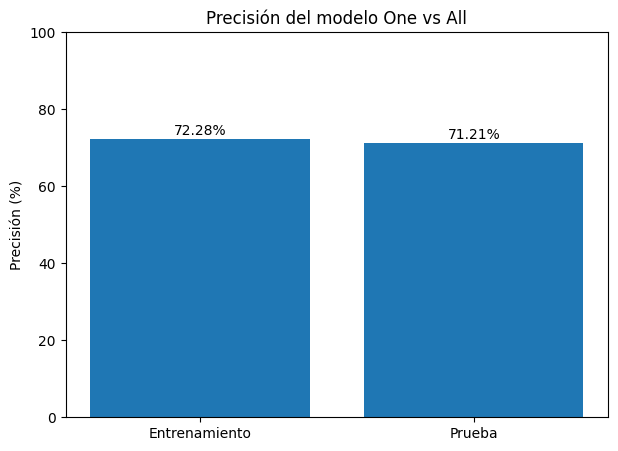

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    resultados_precision["Conjunto"],
    resultados_precision["Precision"]
)

plt.ylim(0, 100)

plt.title(
    "Precisión del modelo One vs All"
)

plt.ylabel("Precisión (%)")

for i, valor in enumerate(
    resultados_precision["Precision"]
):
    plt.text(
        i,
        valor + 1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.show()

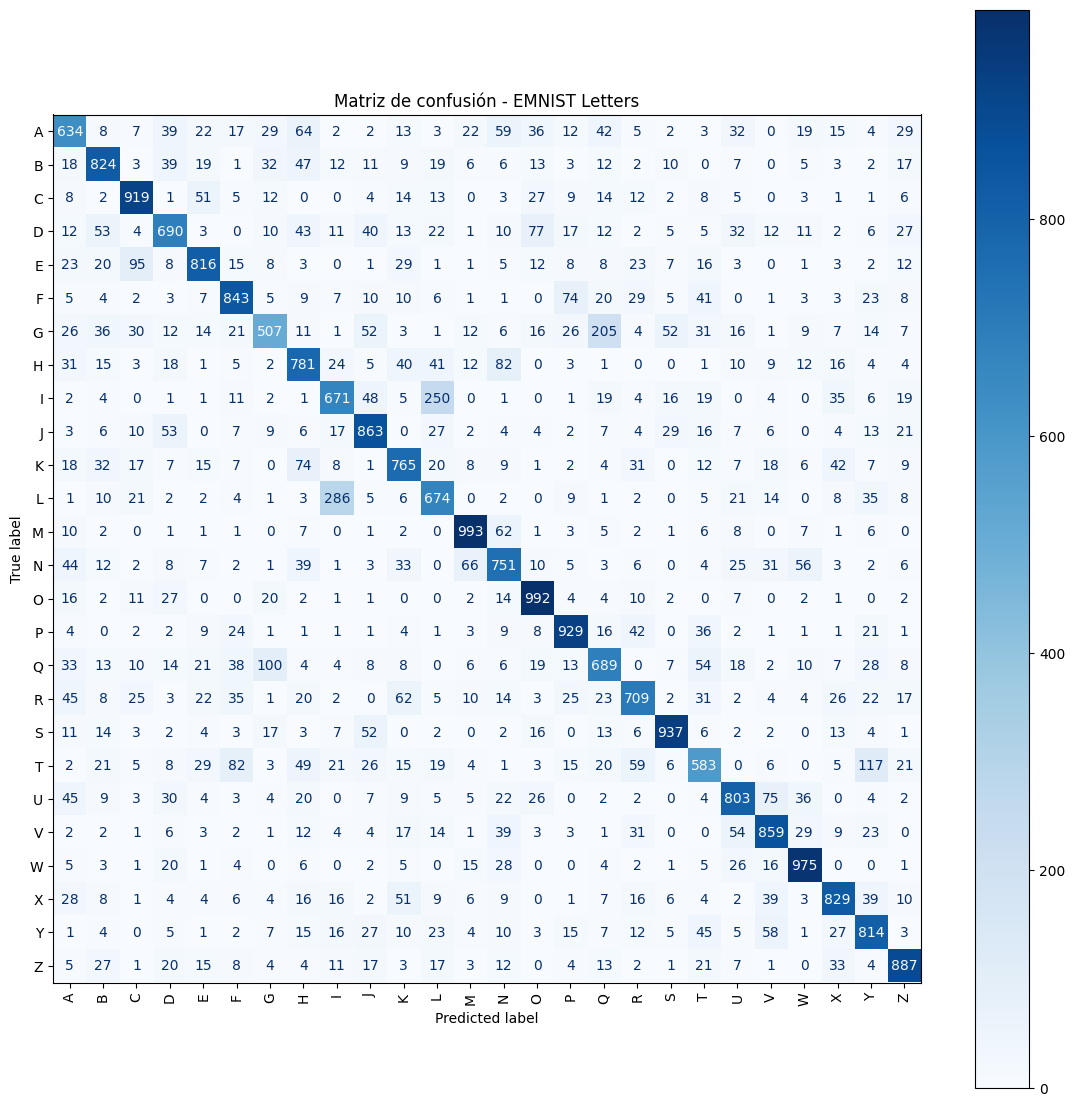

In [31]:
matriz = confusion_matrix(
    y_test,
    pred_test
)

fig, ax = plt.subplots(
    figsize=(14, 14)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nombres_clases
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "Matriz de confusión - EMNIST Letters"
)

plt.show()

In [32]:
reporte = classification_report(
    y_test,
    pred_test,
    target_names=nombres_clases,
    output_dict=True
)

df_reporte = pd.DataFrame(
    reporte
).transpose()

df_reporte.head(26)

,precision,recall,f1-score,support
A,0.614341,0.566071,0.589219,1120.0
B,0.723442,0.735714,0.729526,1120.0
C,0.781463,0.820536,0.800523,1120.0
D,0.674487,0.616071,0.643957,1120.0
E,0.761194,0.728571,0.744526,1120.0
F,0.735602,0.752679,0.744042,1120.0
G,0.650000,0.452679,0.533684,1120.0
H,0.629839,0.697321,0.661864,1120.0
I,0.597507,0.599107,0.598306,1120.0
J,0.723386,0.770536,0.746217,1120.0


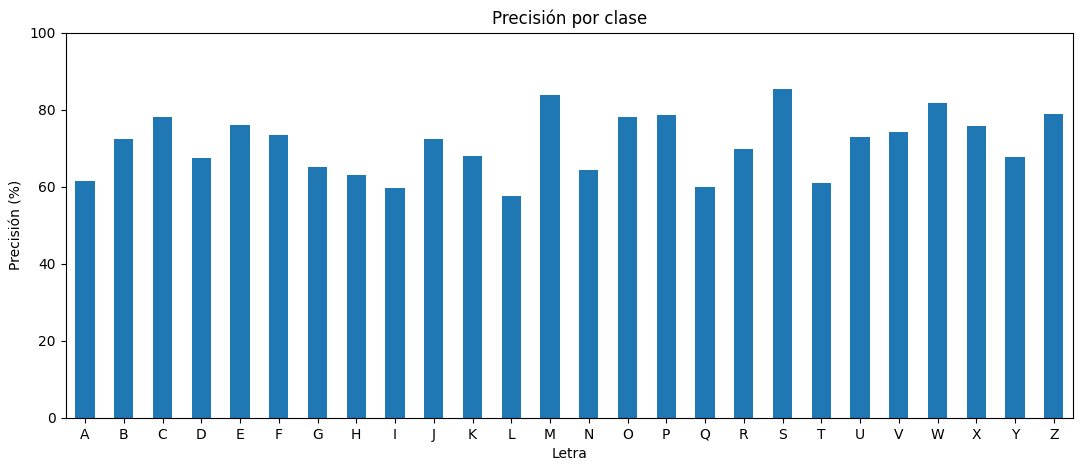

In [33]:
precision_por_clase = (
    df_reporte.loc[
        nombres_clases,
        "precision"
    ] * 100
)

plt.figure(figsize=(13, 5))

precision_por_clase.plot(
    kind="bar"
)

plt.title(
    "Precisión por clase"
)

plt.xlabel("Letra")
plt.ylabel("Precisión (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

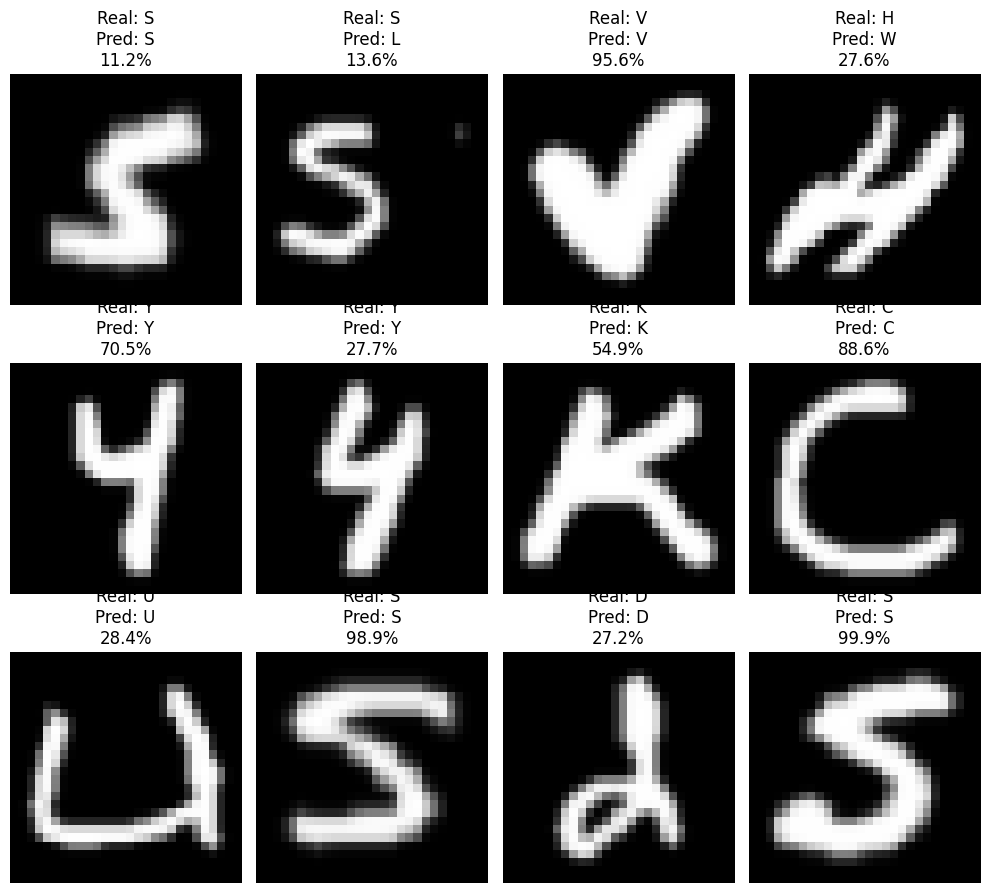

In [34]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 9)
)

for i, ax in enumerate(
    axes.ravel()
):

    imagen = X_test[i].reshape(
        28, 28
    ).T

    real = nombres_clases[
        y_test[i]
    ]

    predicha = nombres_clases[
        pred_test[i]
    ]

    confianza = (
        np.max(prob_test[i]) * 100
    )

    ax.imshow(
        imagen,
        cmap="gray"
    )

    ax.set_title(
        f"Real: {real}\n"
        f"Pred: {predicha}\n"
        f"{confianza:.1f}%"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
indices_correctos = np.where(
    pred_test == y_test
)[0]

indices_incorrectos = np.where(
    pred_test != y_test
)[0]

print(
    "Predicciones correctas:",
    len(indices_correctos)
)

print(
    "Predicciones incorrectas:",
    len(indices_incorrectos)
)

Predicciones correctas: 20737
Predicciones incorrectas: 8383


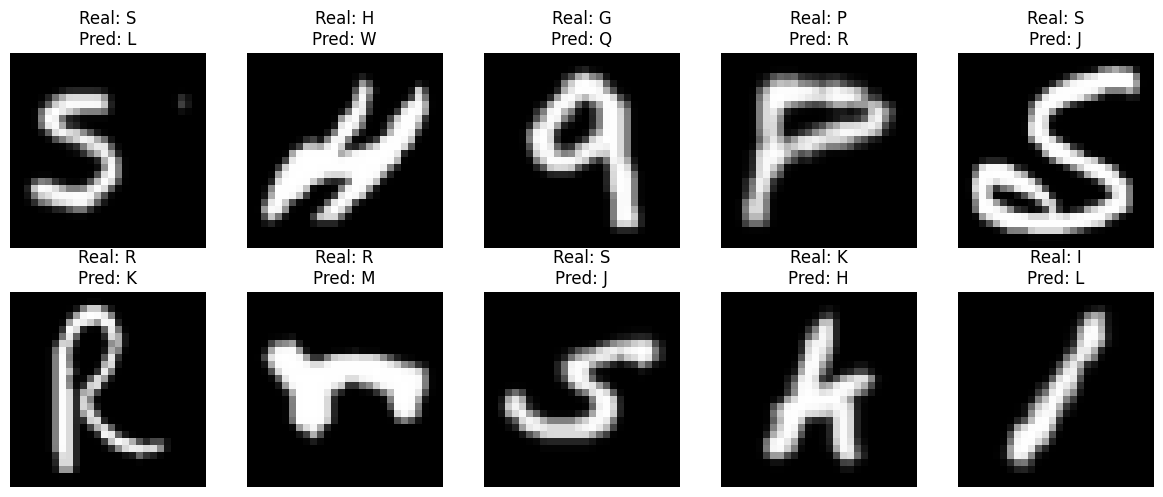

In [36]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for indice, ax in zip(
    indices_incorrectos[:10],
    axes.ravel()
):

    imagen = X_test[
        indice
    ].reshape(28, 28).T

    real = nombres_clases[
        y_test[indice]
    ]

    predicha = nombres_clases[
        pred_test[indice]
    ]

    ax.imshow(
        imagen,
        cmap="gray"
    )

    ax.set_title(
        f"Real: {real}\n"
        f"Pred: {predicha}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()